# Régression

* Modéliser des relations statistiques entre deux variables

* Estimer l'impact de la variation d'une variable explicative sur une variable à expliquer

* Modèle : $y = f(x) + \epsilon$, où $x$ est une variable explicative (entrée), $y$ est une réponse (sortie) et $\epsilon$ un terme d'erreur.

Aide sur Markdown: https://colab.research.google.com/notebooks/markdown_guide.ipynb

# Partie I : Données simulées

## I.1. Régression linéaire

* $f(x) = \langle x, \beta \rangle$

* estimer le vecteur de paramètre $\beta$

a) Générer $n$ données suivant le modèle : $y_i = \beta_0 + \beta_1 x_i + \epsilon_i, i=1,\ldots,n$, avec $n=100$ et des valeurs arbitraires pour $\beta_0$ et $\beta_1$. Afficher les données.

Beta: [0.8444213  0.87067613]


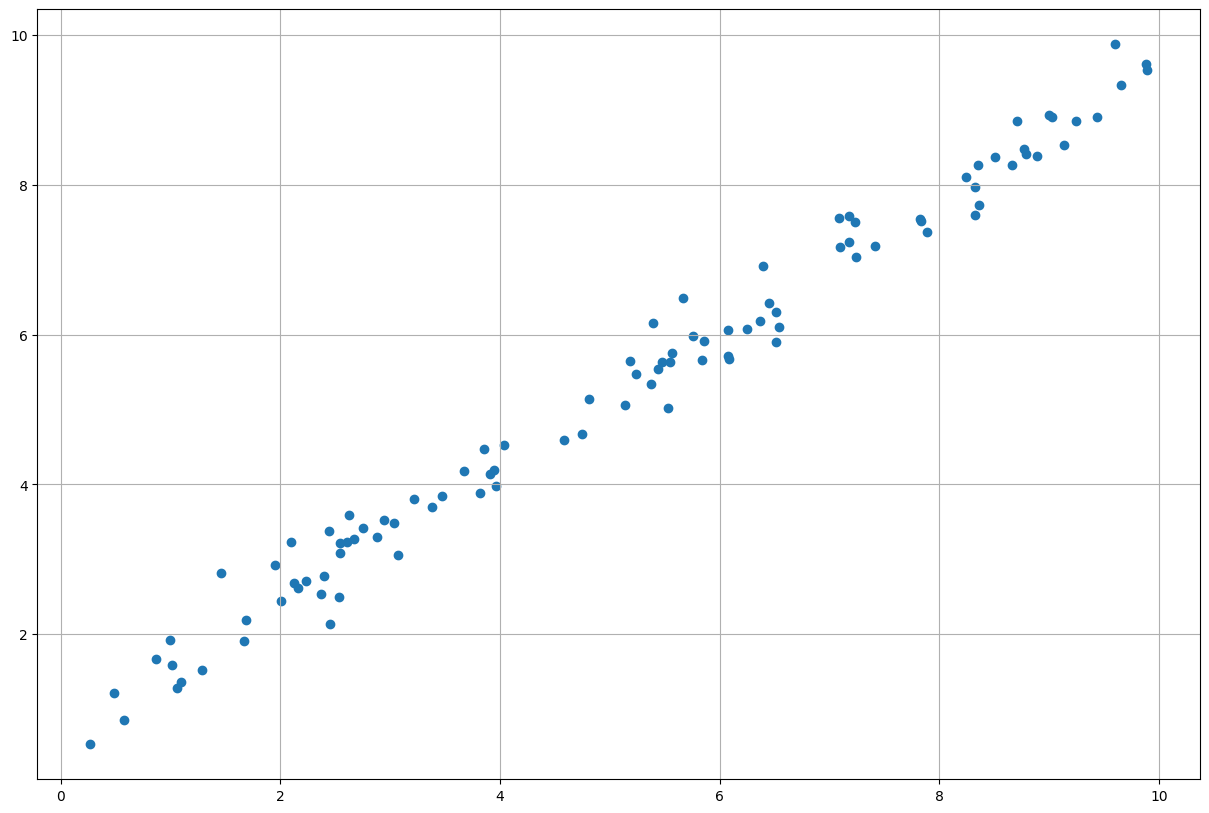

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# A compléter

### Indications :

# Avec l'import : import matplotlib.pyplot as plt
# Si x et y sont deux tableaux de valeurs réelles (abscisses et ordonnées) vous pouvez tracer les points (x,y) avec les commandes:
# plt.figure(figsize=(15,10))
# plt.scatter(x, y)
# plt.grid()

%matplotlib inline


beta_ref = np.random.rand(2)
print('Beta:', beta_ref)

n_examples = 100
sigma = 0.3  # écart-type du bruit
x = np.random.rand(n_examples) * 10
y = x * beta_ref[1] + beta_ref[0] + np.random.randn(n_examples) * sigma
plt.figure(figsize=(15,10))
plt.scatter(x, y)
plt.grid()

b) Calculer la solution obtenue par une régression linéaire à moindres carrés. Tracer la droite de régression obtenue.

Beta: [0.8444213  0.87067613]
Beta estimé: [0.7356069  0.88518785]
Erreur sur Beta: [-0.1088144   0.01451172]


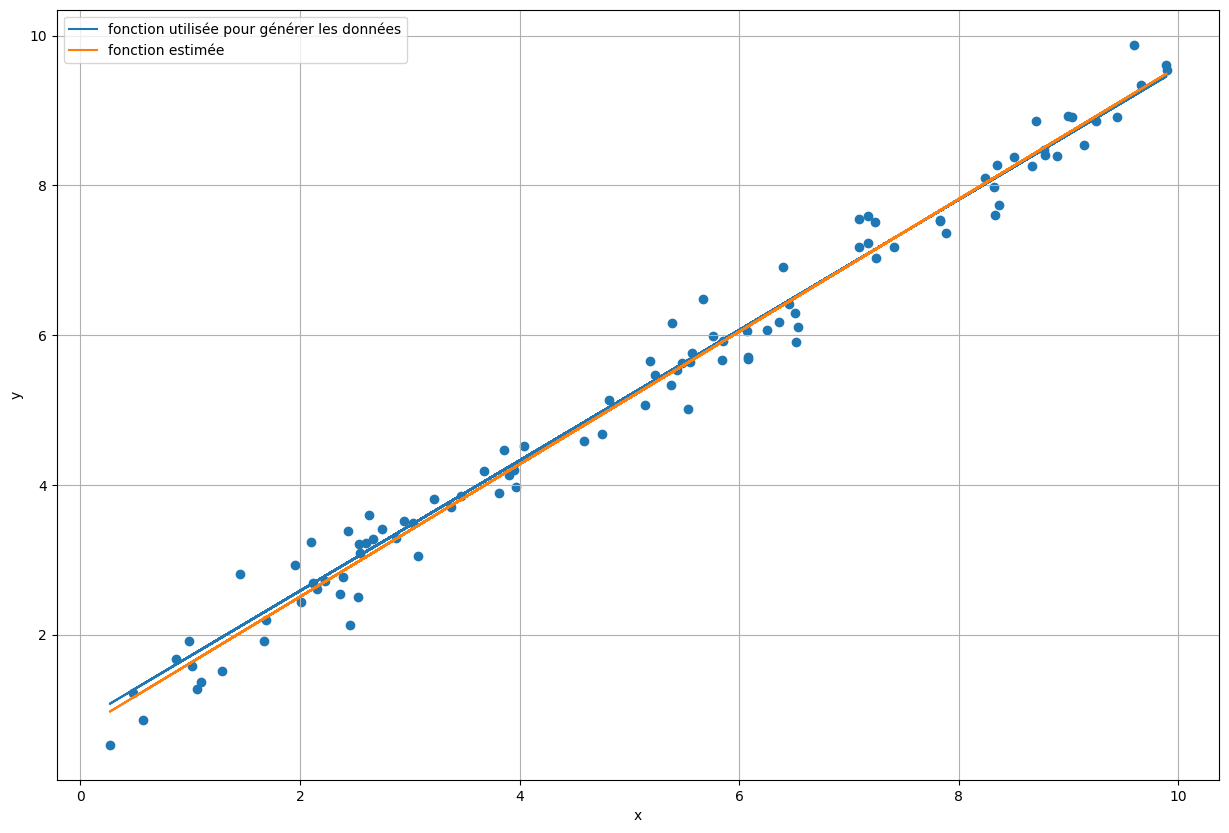

In [3]:
# A compléter

### Indications

# Pour ploter une droite il suffit d'avoir des tableaux x et y d'absicces et d'ordonnées de points sur une droite et d'utiliser
# plt.figure(figsize=(15,10))
# plt.plot(x, y)

# Vous pouvez utiliser aussi
# plt.plot(x, y, label = "ma droite") pour générer automatiquement une légende

# Si vous voulez tracer deux droites sur une même figure (avec les mêmes abscisses par exemple) il vous suffit d'utiliser:
# plt.plot(x, y1, label='ma droite1')
# plt.plot(x, y2, label='ma droite2')

x_moy = np.mean(x)
y_moy = np.mean(y)
beta_est = np.empty(2)
beta_est[1] = np.sum((x - x_moy) * (y - y_moy)) / np.sum((x - x_moy) ** 2)
beta_est[0] = y_moy - beta_est[1] * x_moy
print('Beta:', beta_ref)
print('Beta estimé:', beta_est)
print('Erreur sur Beta:', beta_est - beta_ref)

plt.figure(figsize=(15,10))
plt.scatter(x, y)
plt.plot(x, beta_ref[0] + beta_ref[1] * x, label='fonction utilisée pour générer les données')
plt.plot(x, beta_est[0] + beta_est[1] * x, label='fonction estimée')
plt.grid()
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.savefig('exI_lineaire.png')


## I.2. Régression non linéaire


a) Générer des données suivant le modèle : $y_i = \sin(\frac{x_i}{10}) +(\frac{x_i}{50})^2 + \epsilon $, avec $x_i = i, \forall i =1,\ldots,100$. Afficher les données.

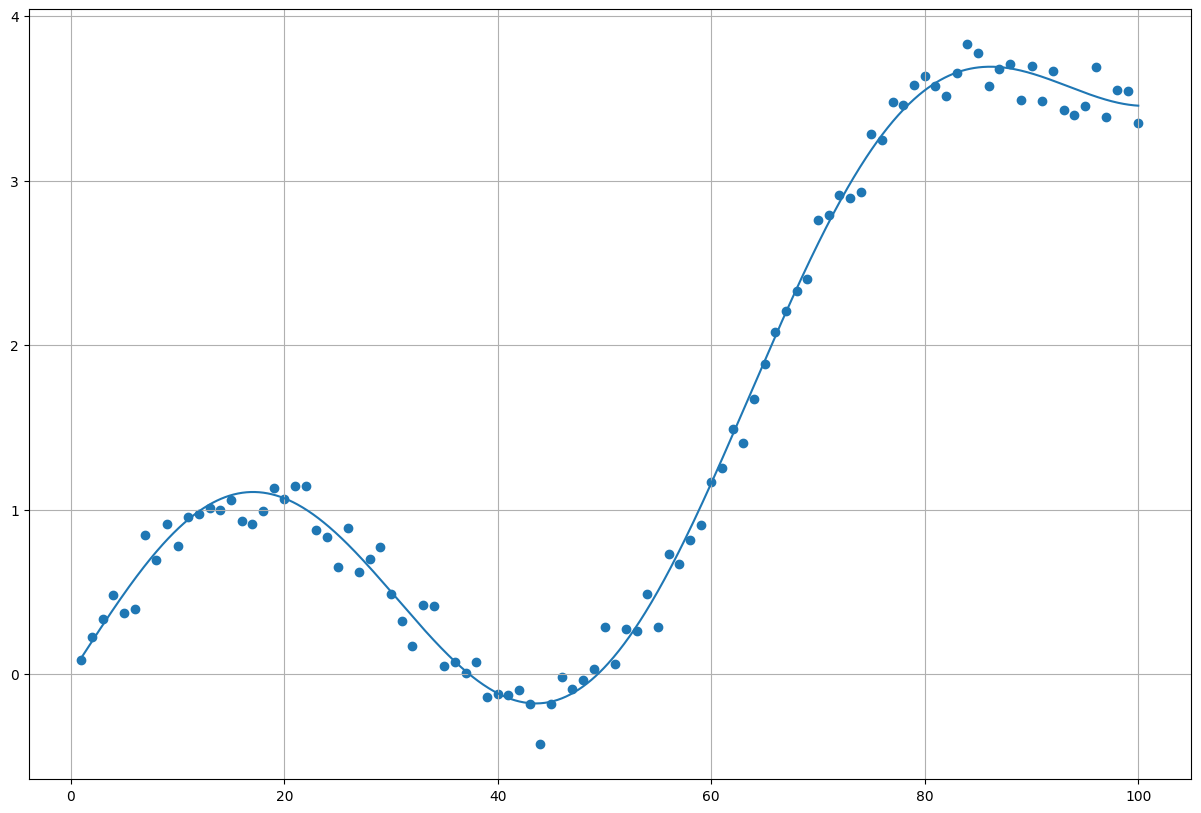

In [5]:
import numpy as np

from matplotlib.pyplot import *

# A compléter

### Indications
# utiliser np.linspace

sigma = 0.1
# x = np.random.rand(n_examples) * 100  # Tirages uniformes entre 0 et 100
x = np.arange(n_examples) + 1
y = np.sin(x / 10) + (x / 50) ** 2 + np.random.randn(n_examples) * sigma

plt.figure(figsize=(15,10))
x_range = np.linspace(np.min(x), np.max(x), 1000)
y_ref = np.sin(x_range / 10) + (x_range / 50) ** 2
plt.scatter(x, y)
plt.plot(x_range, y_ref, label='True')
plt.grid()



### I.2.1. Régression polynomiale

* $y = \beta_0 + \beta_1 x + \beta_2 x^2 +\beta_3 x^3$

* La solution d'une régression linéaire : $\hat{\beta} = (X^\top X)^{-1} X^\top Y$

* Utiliser $X = [1 \ x \ x^2 \ x^3]$


a) Ecrire une fonction qui retourne la solution de la régression linéaire multiple.

In [6]:
# A compléter

### Indications
# utiliser np.concatenate

def learn_regression_poly3(x, y):
    x = x[:, None]  # conversion du vecteur en matrice à une colonne ([n,1])
    # Création des 4 features (puissances de x)
    X = np.concatenate([x ** 0, x ** 1, x ** 2, x ** 3], axis=1)
    # Calcul des coeffcients de la régression linéaire aux moindres carrés
    # return np.linalg.inv(X.T @ X) @ X.T @ y
    return np.linalg.pinv(X) @ y

b) Utilisant la fonction ci-dessus, estimer les paramètres du modèle de régression polynomiale et afficher la solution.

[ 1.47953982e+00 -1.05955572e-01  2.40956532e-03 -1.08080779e-05]


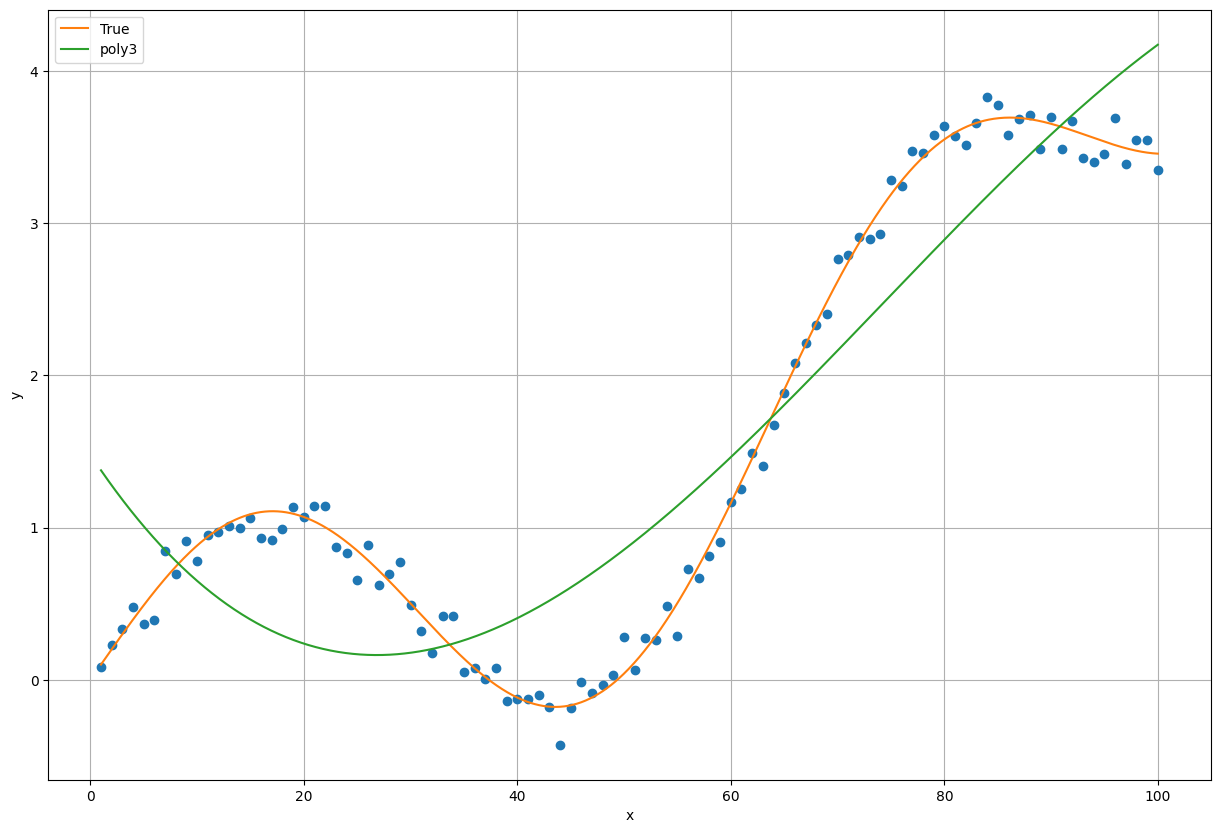

In [7]:
# A compléter

beta_est = learn_regression_poly3(x, y)
print(beta_est)

def predict_regression_poly3(x, beta):
    x = x[:, None]
    X = np.concatenate([x ** 0, x ** 1, x ** 2, x ** 3], axis=1)
    return X @ beta

plt.figure(figsize=(15,10))
plt.plot(x, y, 'o')
plt.plot(x_range, y_ref, label='True')
plt.plot(x_range, predict_regression_poly3(x_range, beta_est), label='poly3')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid()

# Partie II : Données réelles

## II.1. Récupérer et préparer les données

### II.1.1. Récupération

Vous allez travailler sur les données suivantes : https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#, et en particulier sur le fichier day.csv de ce jeu de données.



- Si vous utilisez jupyter notebook sur votre ordinateur, le jeu de données peut être chargé en utilisant la commande suivante :  `data = pd.read_csv('day.csv')` ou `data = pd.read_csv('Bike-Sharing-Dataset/day.csv')` suivant où se trouve le fichier.

- Si vous travaillez sur google colab vous devrez uploader le fichier day.csv sur votre drive et lier l'execution de votre colab notebook avec votre drive pour pouvoir ensuite y accéder comme ci dessus.

Pour lier l'execution de votre colab notebook avec votre drive il suffit d'exécuter au début de votre notebook les instructions :

```
from google.colab import drive
drive.mount('/content/drive')
```
Une fois ces instructions exécutées votre drive est accessible depuis votre notebook et vous pouvez lire ou sauvegarder dans un fichier de votre drive à partir du notebook, par exemple avec:

```
pd.read_csv(...)
```
Il vous faut cependant bien spécifier le chemin vers le fichier.





In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
ls /content/drive/MyDrive/Enseignement/M2_IAAA/Bike-Sharing-Dataset

### II.1.2. Préparation

Pour préparer les données, vous éliminerez les colonnes 'instant', 'dteday', 'casual', 'registered' des données et constituerez les données d'entrée et de sortie afin de prédire la colonne 'cnt' à partir des colonnes restantes.

In [ ]:
# A compléter
import pandas as pd
pd.read_csv('/content/drive/MyDrive/Enseignement/M2_IAAA/Bike-Sharing-Dataset/day.csv')

### Indications

# Vous pouvez charger les données par :
# import pandas as pd
# data = pd.read_csv('day.csv')

# Une fois les données chargées, vous pouvez récupérer la liste des colonnes (attributs) des données par:
# x_cols = list(data.columns)

# Une fois la liste x_cols expurgée des colonnes que l'on ne souhaite pas conserver vous pouvez utiliser:
# X = data[x_cols]
# y = data['cnt']
# pour ne récupérer dans X et Y que les les colonnes que vous souhaitez.

## II.2. Régression Ridge et Lasso

La régression ridge et lasso sont des extensions de la régression linéaire par moindres carrés permettant d'éviter le risque de sur-apprendtissage. L'idée est d'ajouter une pénalisation au problème de régression par moindres carrés:
$$ \arg\min_{w\in\mathbb{R}^d, b\in\mathbb{R}} \sum_{i=1}^n \big(y_i - \langle w, x_i \rangle-b\big)^2 + \lambda \Omega(w),$$
où $\lambda\in\mathbb{R}$ est un paramètre de régularisation, $\Omega(w) = \|w\|_2^2$ pour la régression ridge et $\Omega(w) = \|w\|_1$ pour le Lasso.

a) Utilisant la bibliothèque Scikit-learn, appliquez la régression Ridge et la régression Lasso sur le jeu de données "Bike Sharing". Affichez et comparez les deux solutions obtenues.

In [ ]:
# A compléter


### Indications

# Pour importer et définir un modèle Ridge ou Lasso utilisez :

# from sklearn.linear_model import Ridge, Lasso

# ridge = Ridge()
# ridge.fit(X, y)

# lasso = Lasso()
# lasso.fit(X, y)

# N'oubliez pas que les données X et Y doivent etre des numpy array et pas des pandas frame
# La conversion des X et Y des cellules précédentes peut être réalisée par
# X = np.array(X)

b) Calculez les erreurs de prédiction sur les données d'apprentissage obtenues avec les régressions Ridge et Lasso (utiliser la valeur par défaut de Scikit-learn pour le paramètre de régularisation). Comparez les résultats avec ceux obtenus par la régression par moindre carrés.

In [ ]:
# A compléter

### Indications

# Utilsez la methode predict des estimateurs de sklearn pour obtenir les predictions sur un ensemble de donées d'entrée.
# Par exemple si m est un modèle appris (Ridge, Lasso ou autre) vous pouvez utiliser:
#   m.predict(X)
# pour calculer les sorties calculées par votre modèle pour les données d'entrée X



## II.2.3. Réglage des hyper paramètres par cross validation

Le choix du paramètre $\lambda$ est primordial pour avoir des résultats de prédiction optimaux. Une façon de procéder pour trouver une bonne valeur $\lambda$ est d'utiliser la méthode de cross-validation sur une grille de valeurs. Déterminer par cross-validation les valeurs de $\lambda$ permettant d'avoir les meilleurs taux de prédiction.

Vous tracerez les courbes de performance en validation (ordonnée) en fonction de $\lambda$ (abscisse) pour les modèles Ridge et Lasso.  



In [ ]:
# A compléter

## II.2.4. Analyse du modèle appris

- En examinant les poids du meilleur modèle dont vous disposez, déterminez quels sont les attributs les plus importants pour la tâche de prédiction. Plus le paramètre correspondant à une colonne est petit en valeur absolue moins la caractéristique correspondante est importante.

Quelles sont les caractéristiques ayant le plus de pouvoir prédictif dans ce problème de régression ?

- Reproduisez l'ensemble de l'expérience (apprentissage, choix du meilleur modèle et analyse des paramètres de ce modèle) en normalisant **avant toute chose** les données avec un standard scaler (https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html).

Les résultats sont-ils différents et pourquoi ?



In [ ]:
# A compléter